<a href="https://colab.research.google.com/github/jwlee95/DSP_w_Python2026/blob/main/PDSP_ch11_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 11장 예제:
  - 2차원 신호처리를 다음 순서로 다룬다.    

(1) 2D 컨볼루션 직접 구현(Algorithm 11.1)을 scipy.signal.convolve2d와 비교 검증한다.   
(2) 2D FFT 기반 컨볼루션(곱셈-컨볼루션 쌍대성)이 공간영역 컨볼루션과 일치함을 검증한다.   
(3) 가우시안 커널의 분리성(11.2.2절)을 이용한 2단계 1D 컨볼루션이 완전한 2D 컨볼루션과
    일치함을 검증하고 연산 횟수를 비교한다.   
(4) 합성 테스트 영상에 Sobel 에지검출을 적용한다.   
(5) 합성 의료영상 팬텀에 잡음을 추가한 뒤, 공간영역 가우시안 필터와 Algorithm 11.2(2D FFT  저역통과)로 각각 잡음을 제거하고 성능을 비교한다.   

필요 라이브러리: numpy, scipy, matplotlib  (pip install numpy scipy matplotlib)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['axes.unicode_minus'] = False

In [ ]:
import matplotlib.font_manager as fm

# 현재 시스템에 설정된 폰트 이름 확인
font_list = [f.name for f in fm.fontManager.ttflist]
print(f"총 {len(font_list)}개의 폰트가 발견되었습니다.")

# 상위 20개만 출력하거나, 특정 키워드(예: 'Nanum' 또는 'Sans')가 포함된 폰트 찾기
print("사용 가능한 폰트 예시:", font_list[:20])

총 55개의 폰트가 발견되었습니다.
사용 가능한 폰트 예시: ['DejaVu Sans', 'STIXNonUnicode', 'cmr10', 'DejaVu Serif', 'STIXGeneral', 'STIXSizeThreeSym', 'STIXSizeFourSym', 'STIXSizeTwoSym', 'DejaVu Sans Mono', 'STIXSizeFiveSym', 'DejaVu Serif', 'DejaVu Sans', 'cmsy10', 'STIXSizeTwoSym', 'DejaVu Serif Display', 'STIXSizeFourSym', 'DejaVu Sans Mono', 'STIXGeneral', 'STIXSizeOneSym', 'STIXSizeOneSym']


> 이 셀은 2차원 신호 처리에 필요한 핵심 라이브러리인 numpy (수치 계산), matplotlib.pyplot (시각화), scipy.signal (신호 처리)를 불러옵니다.

In [ ]:
def conv2d_manual(f, h):
    """Algorithm 11.1. 2차원 컨볼루션을 직접(이중 루프로) 계산한다."""
    P, Q = h.shape
    pad_h, pad_w = P // 2, Q // 2
    f_pad = np.pad(f, ((pad_h, pad_h), (pad_w, pad_w)))
    h_flipped = h[::-1, ::-1]
    out = np.zeros_like(f, dtype=float)
    for m in range(f.shape[0]):
        for n in range(f.shape[1]):
            region = f_pad[m:m + P, n:n + Q]
            out[m, n] = np.sum(region * h_flipped)
    return out

### 2D 공간 영역 컨볼루션 (Algorithm 11.1) 설명

이 셀의 `conv2d_manual` 함수는 2차원 공간 영역에서 커널을 이동시키며 직접 연산하는 방식을 구현합니다.

#### 1. 수학적 정의
입력 영상 $f(m, n)$과 커널 $h(m, n)$의 2차원 컨볼루션 $y(m, n)$은 다음과 같이 정의됩니다:
$$y(m, n) = \sum_{i=0}^{P-1} \sum_{j=0}^{Q-1} f(m + i - \text{pad}_h, n + j - \text{pad}_w) \cdot h(P-1-i, Q-1-j)$$
여기서 $P, Q$는 커널의 크기입니다.

#### 2. 주요 구현 단계
1.  **Padding**: 커널이 이미지의 가장자리에서도 연산될 수 있도록 이미지 주변을 0으로 채웁니다. 이때 패딩 크기는 보통 커널 크기의 절반인 $P//2, Q//2$를 사용합니다.
2.  **Kernel Flipping**: 컨볼루션의 정의에 따라 커널을 상하좌우로 뒤집습니다 (`h[::-1, ::-1]`). 만약 뒤집지 않고 그대로 연산하면 이를 **교차 상관(Cross-correlation)**이라고 부릅니다.
3.  **Sliding Window (Double Loop)**:
    - 외부 이중 루프는 이미지의 각 픽셀 $(m, n)$을 순회합니다.
    - `region` 변수를 통해 현재 위치에서 커널 크기만큼의 입력 영역을 추출합니다.
    - 추출된 영역과 뒤집힌 커널을 성분별로 곱하고 모두 더해(`np.sum`) 결과 픽셀 값을 결정합니다.

In [ ]:
def conv2d_via_fft(f, h):
    """식 (11.x): 곱셈-컨볼루션 쌍대성을 이용한 2D FFT 기반 컨볼루션."""
    s1 = np.array(f.shape)
    s2 = np.array(h.shape)
    size = s1 + s2 - 1
    F = np.fft.fft2(f, size)
    H = np.fft.fft2(h, size)
    y_full = np.real(np.fft.ifft2(F * H))
    start = (s2 - 1) // 2
    return y_full[start[0]:start[0] + s1[0], start[1]:start[1] + s1[1]]

### 2D FFT 기반 컨볼루션 (Convolution Theorem)

이 셀의 `conv2d_via_fft` 함수는 공간 영역의 컨볼루션을 주파수 영역의 곱셈으로 변환하여 계산하는 **컨볼루션 정리(Convolution Theorem)**를 구현합니다.

#### 1. 수학적 원리
두 신호 $f$와 $h$의 컨볼루션은 주파수 영역에서 각 신호의 푸리에 변환의 성분별 곱(Element-wise product)과 같습니다:
$$\mathbb{F}_{2D}\{f * h\} = \mathbb{F}_{2D}\{f\} \cdot \mathbb{F}_{2D}\{h\}$$

따라서 최종 결과 $y$는 다음과 같이 역푸리에 변환을 통해 얻을 수 있습니다:
$$y = \mathbb{F}_{2D}^{-1} \{ \mathbb{F}_{2D}\{f\} \cdot \mathbb{F}_{2D}\{h\} \}$$

#### 2. 구현 단계
1.  **Padding**: 원형 컨볼루션(Circular Convolution)에 의한 앨리어싱을 방지하기 위해 출력 크기 $s1 + s2 - 1$에 맞춰 입력을 제로 패딩합니다.
2.  **FFT**: `np.fft.fft2`를 사용하여 두 신호를 주파수 영역 $F$와 $H$로 변환합니다.
3.  **Multiplication**: 주파수 영역에서 두 행렬을 곱합니다 ($F \cdot H$).
4.  **IFFT**: `np.fft.ifft2`를 통해 다시 공간 영역으로 복원하고, 실수부(`np.real`)만 취합니다.
5.  **Cropping**: 패딩된 결과에서 원래 이미지 크기에 해당하는 중앙 부분(`same` 모드와 유사)을 슬라이싱하여 반환합니다.

In [ ]:
def gaussian_kernel2d(size, sigma):
    """11.2.2절의 2차원 가우시안 커널을 생성한다."""
    ax = np.arange(-size // 2 + 1, size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return k / np.sum(k)

### 2차원 가우시안 커널 생성 함수 설명

이 셀의 `gaussian_kernel2d` 함수는 영상 처리에서 블러링(Smoothing)이나 노이즈 제거에 널리 쓰이는 가우시안 필터를 생성합니다.

#### 1. 수학적 정의
2차원 가우시안 함수 $G(x, y)$는 평균이 0일 때 다음과 같이 정의됩니다:
$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$
코드에서는 지수 부분인 $e^{-\frac{x^2 + y^2}{2\sigma^2}}$를 먼저 계산한 후, 커널의 모든 요소의 합이 1이 되도록 정규화(Normalization)를 수행합니다.

#### 2. 코드 구현 상세
1.  **좌표축 생성 (`ax`)**: `-size // 2 + 1`부터 `size // 2`까지의 정수 범위를 생성하여 커널의 중심을 $(0, 0)$으로 맞춥니다.
2.  **격자 생성 (`np.meshgrid`)**: 1차원 좌표축을 바탕으로 2차원 평면상의 모든 점에 대한 $x$ 좌표 행렬(`xx`)과 $y$ 좌표 행렬(`yy`)을 만듭니다.
3.  **지수 연산 (`np.exp`)**: 중심에서의 거리 제곱($x^2 + y^2$)을 이용하여 가우시안 분포의 종 모양(Bell shape) 값을 계산합니다. 여기서 $\sigma$(sigma)는 분포의 퍼짐 정도를 결정합니다.
4.  **정규화 (`k / np.sum(k)`)**: 필터를 적용했을 때 이미지의 전체 밝기가 변하지 않도록 모든 필터 계수의 합을 1로 만듭니다.

In [ ]:
def gaussian_blur_separable(f, size, sigma):
    """11.2.2절: 분리성을 이용해 2D 컨볼루션을 두 번의 1D 컨볼루션으로 대체한다.
    scipy.signal.convolve2d(..., boundary='symm')와 동일한 대칭 경계 처리를 적용하여
    비교 시 경계 부근에서 발생하는 인위적인 차이를 방지한다."""
    ax = np.arange(-size // 2 + 1, size // 2 + 1)
    h1 = np.exp(-ax**2 / (2 * sigma**2))
    h1 = h1 / np.sum(h1)
    pad = size // 2
    f_pad = np.pad(f, pad, mode='symmetric')
    # 가로 방향(각 행에 1D 컨볼루션)
    tmp = np.zeros((f_pad.shape[0], f.shape[1]))
    for i in range(f_pad.shape[0]):
        tmp[i, :] = np.convolve(f_pad[i, :], h1, mode='valid')
    # 세로 방향(각 열에 1D 컨볼루션)
    out = np.zeros_like(f, dtype=float)
    for j in range(f.shape[1]):
        out[:, j] = np.convolve(tmp[:, j], h1, mode='valid')
    return out


### 가우시안 커널의 분리성(Separability)을 이용한 컨볼루션 설명

이 셀의 `gaussian_blur_separable` 함수는 2차원 가우시안 커널이 가로와 세로 방향의 1차원 커널로 분리될 수 있다는 성질을 이용하여 연산 효율을 높입니다.

#### 1. 수학적 원리
2차원 가우시안 함수 $G(x, y)$는 다음과 같이 두 1차원 함수의 곱으로 나타낼 수 있습니다:
$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}} = \left( \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{x^2}{2\sigma^2}} \right) \cdot \left( \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{y^2}{2\sigma^2}} \right) = g(x) \cdot g(y)$$

따라서 영상 $f$에 대한 2차원 컨볼루션은 두 번의 1차원 컨볼루션으로 수행 가능합니다:
$$f * G = (f * g_x) * g_y$$

#### 2. 구현 단계 및 장점
1.  **1차원 커널 생성 (`h1`)**: 2차원 격자 대신 1차원 좌표축(`ax`)에 대해서만 가우시안 값을 계산합니다.
2.  **행 방향 컨볼루션**: 이미지의 각 행(Horizontal)에 대해 1차원 커널을 적용하여 중간 결과 `tmp`를 생성합니다.
3.  **열 방향 컨볼루션**: `tmp`의 각 열(Vertical)에 대해 다시 1차원 커널을 적용하여 최종 결과 `out`을 얻습니다.
4.  **효율성**: 커널 크기가 $K$일 때, 2D 컨볼루션은 픽셀당 $K^2$번의 곱셈이 필요하지만, 분리형은 $2K$번의 곱셈만 필요하므로 연산 속도가 비약적으로 향상됩니다.

In [ ]:
def fft_lowpass_filter(f, r_cutoff):
    """Algorithm 11.2. 2D FFT 기반 저역통과 필터링."""
    F = np.fft.fft2(f)
    F_shift = np.fft.fftshift(F)
    M, N = f.shape
    k0, l0 = M // 2, N // 2
    kk, ll = np.meshgrid(np.arange(M), np.arange(N), indexing='ij')
    dist = np.sqrt((kk - k0)**2 + (ll - l0)**2)
    mask = dist <= r_cutoff
    F_filtered = F_shift * mask
    y = np.real(np.fft.ifft2(np.fft.ifftshift(F_filtered)))
    return y

### 2D FFT 기반 저역통과 필터링 (Algorithm 11.2) 설명

이 셀의 `fft_lowpass_filter` 함수는 영상을 주파수 영역으로 변환한 뒤, 급격한 변화를 나타내는 고주파 성분을 제거하여 잡음을 줄이거나 이미지를 부드럽게 만듭니다.

#### 1. 수학적 원리
주파수 영역에서 중심으로부터의 거리 $D(k, l)$이 차단 주파수 $r_{cutoff}$보다 큰 성분을 제거하는 **이상적 저역통과 필터(Ideal Low-pass Filter)** $H(k, l)$를 적용합니다:

$$H(k, l) = \begin{cases} 1 & \text{if } D(k, l) \le r_{cutoff} \\ 0 & \text{if } D(k, l) > r_{cutoff} \end{cases}$$

여기서 $D(k, l) = \sqrt{(k - k_0)^2 + (l - l_0)^2}$ 이며, $(k_0, l_0)$는 주파수 평면의 중심 좌표입니다.

#### 2. 구현 단계
1.  **FFT & Shift**: `np.fft.fft2`로 영상을 변환한 후, `np.fft.fftshift`를 사용하여 저주파 성분이 행렬의 중앙에 오도록 위치를 옮깁니다.
2.  **Distance Map**: `np.meshgrid`를 이용해 각 주파수 성분이 중심에서 얼마나 떨어져 있는지 계산합니다 (`dist`).
3.  **Masking**: `dist <= r_cutoff` 조건을 만족하는 영역만 1, 나머지는 0인 이진 마스크를 생성하여 주파수 행렬에 곱합니다.
4.  **Inverse FFT**: `ifftshift`로 주파수 성분을 원래 위치로 되돌린 후, 역푸리에 변환(`ifft2`)을 수행하여 다시 공간 영역의 영상으로 복원합니다.

In [ ]:
def synthetic_test_image(size=100):
    """11.5절: 에지검출 시연용 합성 테스트 영상 (사각형 + 원)."""
    img = np.zeros((size, size))
    img[20:80, 20:50] = 1.0
    y, x = np.mgrid[0:size, 0:size]
    img += 0.8 * (((x - 70)**2 + (y - 65)**2) <= 15**2)
    return np.clip(img, 0, 1)

### 합성 테스트 영상 생성 함수 (`synthetic_test_image`) 설명

이 셀의 함수는 에지 검출 알고리즘의 성능을 확인하기 위해 인위적으로 사각형과 원이 포함된 영상을 생성합니다.

#### 1. 수학적 구성
1.  **배경**: 모든 값이 0인 $size \times size$ 크기의 행렬을 생성합니다.
2.  **사각형 (Rectangle)**: 이미지의 특정 인덱스 범위에 값 1.0을 할당합니다.
    $$f(y, x) = 1.0 \quad \text{for } 20 \le y < 80, 20 \le x < 50$$
3.  **원 (Circle)**: 원의 방정식을 이용하여 중심 $(x_c, y_c) = (70, 65)$, 반지름 $r = 15$인 영역에 0.8의 밝기를 더합니다.
    $$f(y, x) \mathrel{+}= 0.8 \quad \text{if } (x - 70)^2 + (y - 65)^2 \le 15^2$$

#### 2. 구현 상세
- **`np.mgrid`**: 이미지 전체 좌표에 대한 $x, y$ 격자 행렬을 생성하여 원의 방정식을 행렬 연산으로 한 번에 계산할 수 있게 합니다.
- **`np.clip(img, 0, 1)`**: 사각형과 원이 겹치는 부분에서 밝기 합이 1.0을 초과할 수 있으므로, 모든 픽셀 값을 $[0, 1]$ 범위로 제한하여 유효한 영상 밝기 범위를 유지합니다.

In [ ]:
def synthetic_phantom(size=128):
    """11.5절: 합성 의료영상 유사 팬텀 (두개골 경계 + 내부 병변 유사 구조 3개)."""
    y, x = np.mgrid[0:size, 0:size]
    cx, cy = size / 2, size / 2
    img = np.zeros((size, size))
    img += 0.6 * (((x - cx) / 45)**2 + ((y - cy) / 55)**2 <= 1)
    img += 0.3 * (((x - cx + 15) / 12)**2 + ((y - cy - 10) / 12)**2 <= 1)
    img += 0.4 * (((x - cx - 18) / 10)**2 + ((y - cy + 8) / 10)**2 <= 1)
    img -= 0.2 * (((x - cx) / 20)**2 + ((y - cy) / 20)**2 <= 1)
    return np.clip(img, 0, None)

### 합성 의료영상 팬텀 생성 함수 (`synthetic_phantom`) 설명

이 함수는 실제 의료 영상(CT, MRI 등)의 특성을 모사하기 위해 여러 개의 타원(Ellipse) 구조를 결합하여 팬텀 영상을 생성합니다.

#### 1. 수학적 원리 (타원의 방정식)
좌표 $(x, y)$가 중심이 $(x_c, y_c)$이고 장축과 단축의 길이가 각각 $a, b$인 타원 내부에 있는지 판단하는 식은 다음과 같습니다:
$$\left( \frac{x - x_c}{a} \right)^2 + \left( \frac{y - y_c}{b} \right)^2 \le 1$$

#### 2. 구성 요소
1.  **두개골 경계 (Outer Boundary)**: 중심에 위치한 큰 타원을 생성하여 배경 밝기를 0.6으로 설정합니다.
2.  **내부 구조 (Internal Structures)**: 서로 다른 위치와 크기를 가진 두 개의 작은 타원을 추가하여 각각 0.3, 0.4의 밝기를 더합니다.
3.  **공공(Cavity) 또는 저밀도 영역**: 중심 부근의 원형 영역에서 밝기 값을 0.2만큼 빼서 내부 구조를 복잡하게 만듭니다.

#### 3. 구현 상세
- **`np.mgrid`**: 전체 이미지 크기에 대한 좌표 행렬을 생성하여 수식을 행렬 연산으로 빠르게 처리합니다.
- **`np.clip(img, 0, None)`**: 내부 구조를 빼는 과정에서 픽셀 값이 음수(< 0)가 되는 것을 방지하여 물리적으로 유효한 밝기 범위를 유지합니다.

### 전체 알고리즘 검증 및 응용 시연 (`__main__` 블록)

이 셀은 앞서 정의한 함수들을 사용하여 알고리즘의 정확성을 검증하고 실제 영상 처리 응용 사례를 시연합니다.

#### 1. 주요 검증 및 수행 내용
1.  **컨볼루션 비교**: 직접 구현한 2D 컨볼루션과 FFT 기반 컨볼루션이 `scipy` 라이브러리 결과와 수치적으로 일치하는지 확인합니다.
2.  **가우시안 분리성 확인**: 2D 커널을 두 번의 1D 컨볼루션으로 수행했을 때의 정확도와 연산 효율성(약 4.5배 절감)을 측정합니다.
3.  **에지 검출 (Sobel)**: 합성 영상을 대상으로 $x, y$ 방향의 기울기(Gradient)를 계산하여 물체의 윤곽선을 추출합니다.
4.  **잡음 제거 성능 비교**: 잡음이 섞인 의료용 팬텀 영상에 대해 공간 영역 필터와 주파수 영역(FFT) 필터의 MSE(Mean Squared Error) 개선 정도를 비교합니다.

#### 2. 시각화 구성
- **그림 1**: 합성 영상에서의 Sobel 에지 검출 결과 및 에지 맵.
- **그림 2**: 원본, 잡음 섞인 영상, 그리고 두 가지 필터링 기법을 적용한 복원 영상 비교.
- **그림 3**: 잡음 유무에 따른 2차원 주파수 스펙트럼의 변화(중심이 저주파, 가장자리가 고주파).

=== (1)~(2) 2D 컨볼루션 구현 검증 ===
직접 구현(Algorithm 11.1) vs scipy.signal.convolve2d 최대 차이: 6.661e-16
2D FFT 기반(곱셈-컨볼루션 쌍대성) vs scipy.signal.convolve2d 최대 차이: 1.332e-15

=== (3) 가우시안 커널의 분리성 검증 (11.2.2절) ===
완전한 2D 컨볼루션 vs 분리된 1D x 1D 컨볼루션 최대 차이: 4.441e-16
연산 횟수(곱셈 기준): 완전한 2D = 32400, 분리형 = 7200 (약 4.5배 절감)

=== (4) Sobel 에지검출 ===
에지 강도 최댓값: 4.2426
평탄한 배경 영역의 평균 에지 강도: 0.0000 (0에 가까울수록 정상)

=== (5) 합성 의료영상 팬텀 잡음 제거 ===
잡음 제거 전 MSE: 0.02227
공간영역 가우시안 필터 후 MSE: 0.00361 (개선 비율 6.18배)
2D FFT 저역통과(Algorithm 11.2) 후 MSE: 0.00458 (개선 비율 4.86배)


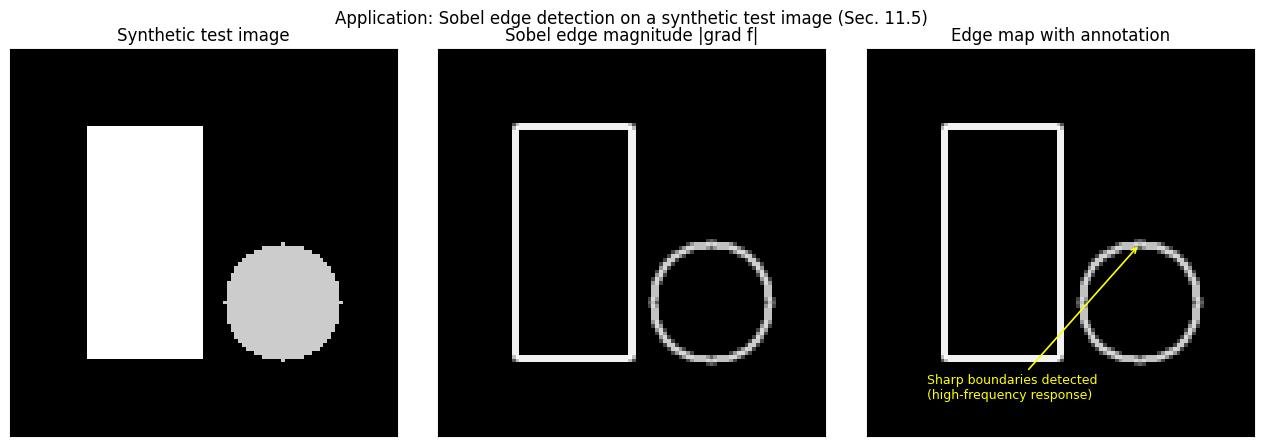

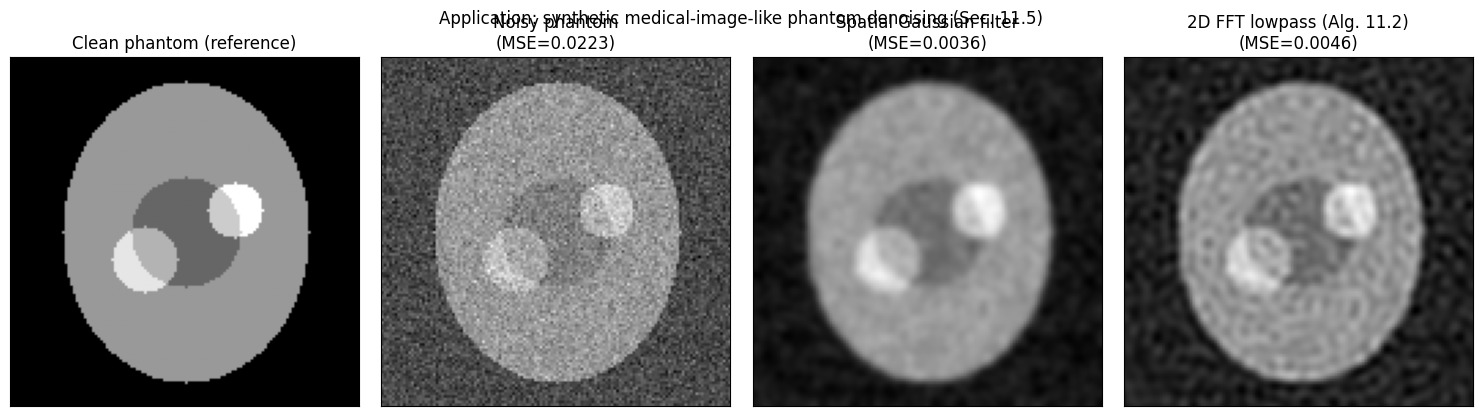

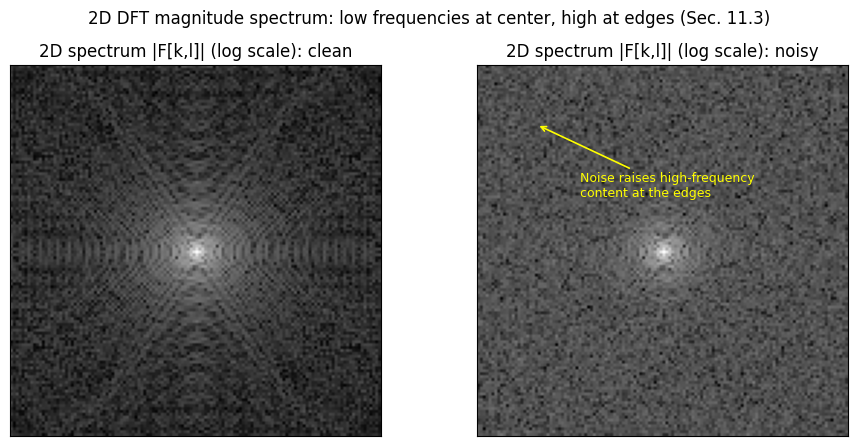

In [ ]:

if __name__ == "__main__":
    # ------------------------------------------------------------------
    # (1)~(2) 2D 컨볼루션 구현 검증
    # ------------------------------------------------------------------
    print("=== (1)~(2) 2D 컨볼루션 구현 검증 ===")
    rng = np.random.default_rng(0)
    test_img_small = rng.random((20, 20))
    sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=float)

    out_manual = conv2d_manual(test_img_small, sobel_x)
    out_scipy = signal.convolve2d(test_img_small, sobel_x, mode='same', boundary='fill')
    out_fft = conv2d_via_fft(test_img_small, sobel_x)
    print(f"직접 구현(Algorithm 11.1) vs scipy.signal.convolve2d 최대 차이: "
          f"{np.max(np.abs(out_manual - out_scipy)):.3e}")
    print(f"2D FFT 기반(곱셈-컨볼루션 쌍대성) vs scipy.signal.convolve2d 최대 차이: "
          f"{np.max(np.abs(out_fft - out_scipy)):.3e}")

    # ------------------------------------------------------------------
    # (3) 가우시안 커널 분리성 검증
    # ------------------------------------------------------------------
    print("\n=== (3) 가우시안 커널의 분리성 검증 (11.2.2절) ===")
    kernel_g = gaussian_kernel2d(9, 1.5)
    out_2d = signal.convolve2d(test_img_small, kernel_g, mode='same', boundary='symm')
    out_separable = gaussian_blur_separable(test_img_small, 9, 1.5)
    print(f"완전한 2D 컨볼루션 vs 분리된 1D x 1D 컨볼루션 최대 차이: "
          f"{np.max(np.abs(out_2d - out_separable)):.3e}")
    ops_2d = test_img_small.size * 9 * 9
    ops_separable = test_img_small.size * (9 + 9)
    print(f"연산 횟수(곱셈 기준): 완전한 2D = {ops_2d:.0f}, 분리형 = {ops_separable:.0f} "
          f"(약 {ops_2d/ops_separable:.1f}배 절감)")

    # ------------------------------------------------------------------
    # (4) 에지검출 (Sobel)
    # ------------------------------------------------------------------
    print("\n=== (4) Sobel 에지검출 ===")
    test_img = synthetic_test_image()
    sobel_y = sobel_x.T
    Gx = signal.convolve2d(test_img, sobel_x, mode='same', boundary='symm')
    Gy = signal.convolve2d(test_img, sobel_y, mode='same', boundary='symm')
    edge_magnitude = np.sqrt(Gx**2 + Gy**2)
    print(f"에지 강도 최댓값: {edge_magnitude.max():.4f}")
    print(f"평탄한 배경 영역의 평균 에지 강도: {edge_magnitude[5:15, 5:15].mean():.4f} (0에 가까울수록 정상)")

    # ------------------------------------------------------------------
    # (5) 합성 의료영상 팬텀의 잡음 제거
    # ------------------------------------------------------------------
    print("\n=== (5) 합성 의료영상 팬텀 잡음 제거 ===")
    phantom = synthetic_phantom()
    rng2 = np.random.default_rng(1)
    noisy_phantom = phantom + 0.15 * rng2.standard_normal(phantom.shape)

    denoised_spatial = signal.convolve2d(noisy_phantom, gaussian_kernel2d(9, 1.5),
                                           mode='same', boundary='symm')
    denoised_freq = fft_lowpass_filter(noisy_phantom, r_cutoff=25)

    mse_before = np.mean((noisy_phantom - phantom)**2)
    mse_spatial = np.mean((denoised_spatial - phantom)**2)
    mse_freq = np.mean((denoised_freq - phantom)**2)
    print(f"잡음 제거 전 MSE: {mse_before:.5f}")
    print(f"공간영역 가우시안 필터 후 MSE: {mse_spatial:.5f} (개선 비율 {mse_before/mse_spatial:.2f}배)")
    print(f"2D FFT 저역통과(Algorithm 11.2) 후 MSE: {mse_freq:.5f} (개선 비율 {mse_before/mse_freq:.2f}배)")

    # ==================================================================
    # 시각화
    # ==================================================================
    # 그림 1: Sobel 에지검출 결과
    fig1, axes1 = plt.subplots(1, 3, figsize=(13, 4.5), facecolor='white')
    for ax in axes1:
        ax.set_facecolor('white')
        ax.set_xticks([]); ax.set_yticks([])
    axes1[0].imshow(test_img, cmap='gray')
    axes1[0].set_title('Synthetic test image')
    axes1[1].imshow(edge_magnitude, cmap='gray')
    axes1[1].set_title('Sobel edge magnitude |grad f|')
    axes1[2].imshow(edge_magnitude, cmap='gray')
    axes1[2].annotate('Sharp boundaries detected\n(high-frequency response)',
                        xy=(70, 50), xytext=(15, 90), fontsize=9, color='yellow',
                        arrowprops=dict(arrowstyle='->', color='yellow', lw=1.2))
    axes1[2].set_title('Edge map with annotation')
    fig1.suptitle('Application: Sobel edge detection on a synthetic test image (Sec. 11.5)')
    fig1.tight_layout()

    # 그림 2: 합성 의료영상 팬텀 잡음 제거 비교
    fig2, axes2 = plt.subplots(1, 4, figsize=(15, 4.2), facecolor='white')
    for ax in axes2:
        ax.set_facecolor('white')
        ax.set_xticks([]); ax.set_yticks([])
    axes2[0].imshow(phantom, cmap='gray')
    axes2[0].set_title('Clean phantom (reference)')
    axes2[1].imshow(noisy_phantom, cmap='gray')
    axes2[1].set_title(f'Noisy phantom\n(MSE={mse_before:.4f})')
    axes2[2].imshow(denoised_spatial, cmap='gray')
    axes2[2].set_title(f'Spatial Gaussian filter\n(MSE={mse_spatial:.4f})')
    axes2[3].imshow(denoised_freq, cmap='gray')
    axes2[3].set_title(f'2D FFT lowpass (Alg. 11.2)\n(MSE={mse_freq:.4f})')
    fig2.suptitle('Application: synthetic medical-image-like phantom denoising (Sec. 11.5)')
    fig2.tight_layout()

    # 그림 3: 2D 주파수영역 스펙트럼 (팬텀과 잡음 섞인 팬텀 비교)
    fig3, axes3 = plt.subplots(1, 2, figsize=(9.5, 4.5), facecolor='white')
    for ax in axes3:
        ax.set_facecolor('white')
        ax.set_xticks([]); ax.set_yticks([])
    spec_clean = np.log(np.abs(np.fft.fftshift(np.fft.fft2(phantom))) + 1)
    spec_noisy = np.log(np.abs(np.fft.fftshift(np.fft.fft2(noisy_phantom))) + 1)
    axes3[0].imshow(spec_clean, cmap='gray')
    axes3[0].set_title('2D spectrum |F[k,l]| (log scale): clean')
    axes3[1].imshow(spec_noisy, cmap='gray')
    axes3[1].set_title('2D spectrum |F[k,l]| (log scale): noisy')
    axes3[1].annotate('Noise raises high-frequency\ncontent at the edges',
                        xy=(20, 20), xytext=(35, 45), fontsize=9, color='yellow',
                        arrowprops=dict(arrowstyle='->', color='yellow', lw=1.2))
    fig3.suptitle('2D DFT magnitude spectrum: low frequencies at center, high at edges (Sec. 11.3)')
    fig3.tight_layout()

    plt.show()